In [78]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import yaml
from pathlib import Path

import EI.ei_original as ut
import EI.ei_open_loop as eol
import EI.ei_unified as eu
import EI.ei_jax as ej

from utils.logger import logger, tqdm_bar

cosmetics

In [59]:
plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 8,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]


OUT = "/home/kzeleznikar/IJS-F1/Koda/equilibrium_EI/plots/"
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png", dpi=300)


config

In [60]:
cfg_path = Path("config/config_eq.yaml")

with cfg_path.open("r") as f:
    cfg = yaml.safe_load(f)

md = cfg["model"]
eq = cfg["equilibrium"]

nk = md["nk"]
nt = md["nt"]
bp = md["band"]["pars"]


gap = bp["gap"]
ta = bp["ta"]
tb = bp["tb"]
v = md["mean_field"]["v"]
n = md["mean_field"]["n"]
uh = md["mean_field"]["uh"]

bd = eu.tb_2d(nk, **bp)

p = eu.MFPars(**md["mean_field"])


In [61]:
s0 = eu.solve_eq(bd, p, **eq["initial"], **eq["solve"])

d0 = abs(s0.d)
mu0 = s0.mu

# za normalizacijo
tc = eu.critical_temperature(bd, p, **eq["critical"])

logger.info(f"Delta_0 = {d0}")
logger.info(f"T_c     = {tc}")
logger.info(f"mu0     = {mu0}")

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[11:16:07] [INFO    ] Delta_0 = 1.343845325358389
[11:16:07] [INFO    ] T_c     = 0.6195544337972998
[11:16:07] [INFO    ] mu0     = 1.3589312191247527


In [62]:
va = np.linspace(0.0, 8.0, 6)
t = 0.1

# window okoli Gamma
kw = 1 * np.pi

nk1 = int(round(np.sqrt(bd.ea.size)))
c = nk1 // 2

ka = 2.0 * np.pi * (np.arange(nk1) - c) / nk1
im = np.abs(ka) <= kw
kx = ka[im]

eaa = np.empty((va.size, kx.size))
eba = np.empty_like(eaa)
da = np.empty(va.size)
mua = np.empty(va.size)

d = max(abs(s0.d), 1.0e-3)
m = s0.m

bar = tqdm(range(va.size), desc="V sweep")

for q in bar:
    v0 = va[q]

    pq = eu.MFPars(
        v=float(v0),
        n=p.n,
        uh=None,
    )

    sq = eu.solve_eq(
        bd,
        pq,
        t=t,
        d=max(abs(d), 1.0e-3),
        m=m,
        mix=(0.15, 0.15),
        tol=1.0e-7,
        nmax=20000,
        chk=20,
        prog=False,
    )

    st = ej.mf_state(
        bd,
        pq,
        sq.d,
        sq.m,
    )

    ea = np.asarray(st.e[0]).reshape(nk1, nk1)
    eb = np.asarray(st.e[1]).reshape(nk1, nk1)

    # ky = 0 and energies relative to mu
    # eaa[q] = ea[im, c] - sq.mu
    eaa[q] = ea[im, c] - sq.mu
    # eba[q] = eb[im, c] - sq.mu
    eba[q] = eb[im, c] - sq.mu

    da[q] = abs(sq.d)
    mua[q] = sq.mu

    d = sq.d
    m = sq.m

    bar.set_postfix(
        v=f"{v0:.2f}",
        d=f"{abs(sq.d):.3e}",
        mu=f"{sq.mu:.3f}",
    )

V sweep:   0%|          | 0/6 [00:00<?, ?it/s]

Plotting:   0%|          | 0/6 [00:00<?, ?it/s]

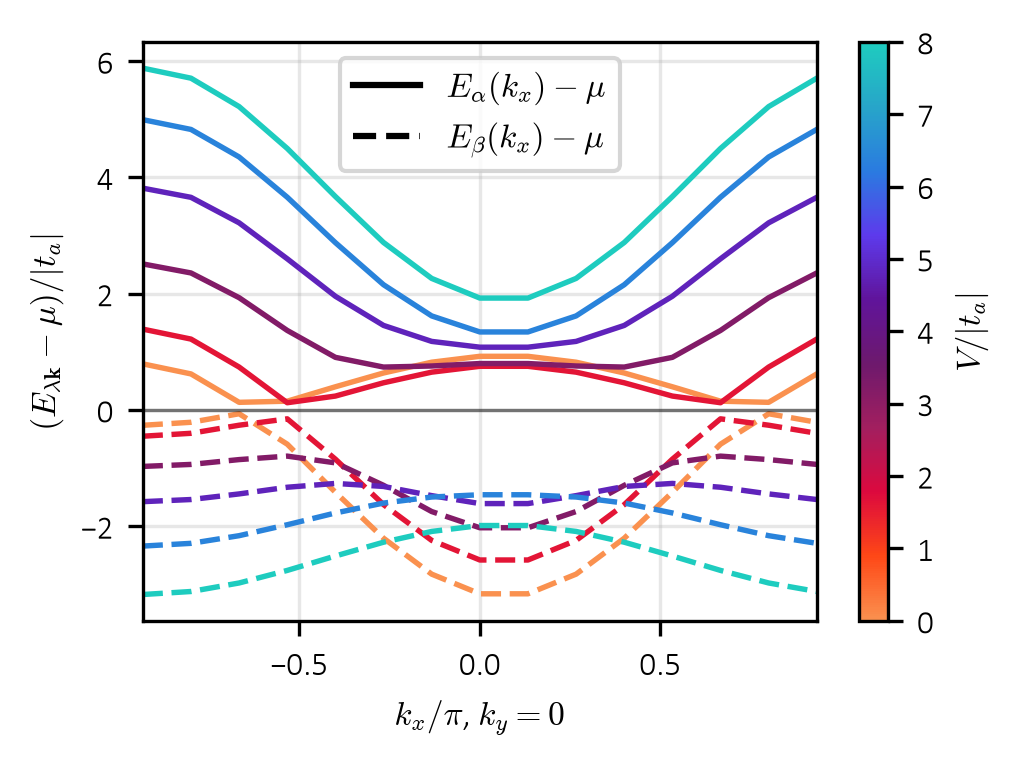

In [63]:
norm = Normalize(vmin=va.min(), vmax=va.max())
cm = bgr_custom
sm = ScalarMappable(norm=norm, cmap=cm)
sm.set_array([])

h = 0.75
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

for q in tqdm(range(va.size), desc="Plotting"):
    cl = cm(norm(va[q]))

    ax.plot(
        kx / np.pi,
        eaa[q],
        color=cl,
        linestyle="-",
        linewidth=1.3,
    )

    ax.plot(
        kx / np.pi,
        eba[q],
        color=cl,
        linestyle="--",
        linewidth=1.3,
    )

ax.plot(
    [],
    [],
    color="black",
    linestyle="-",
    label=r"$E_{\alpha}(k_x)-\mu$",
)

ax.plot(
    [],
    [],
    color="black",
    linestyle="--",
    label=r"$E_{\beta}(k_x)-\mu$",
)

ax.axhline(
    0.0,
    color="black",
    linewidth=0.8,
    alpha=0.5,
)

ax.set_xlim(kx[0] / np.pi, kx[-1] / np.pi)
ax.set_xlabel(r"$k_x/\pi$, $k_y=0$")
ax.set_ylabel(r"$(E_{\lambda\mathbf{k}}-\mu)/|t_a|$")

ax.grid(alpha=0.3)
ax.legend(loc="best")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$V/|t_a|$", rotation=90, labelpad=5)

plt.tight_layout()
plt.show()

In [64]:
tba = np.array([-1.0, -0.7, -0.5, -0.3])
xn = np.linspace(0.1, 2.0, nt)
tca = np.empty(tba.size)

pq = eu.MFPars(
    v=v,
    n=n,
    uh=uh,
)

mua = np.full((tba.size, nt), np.nan)
dda = np.full_like(mua, np.nan)
mma = np.full_like(mua, np.nan)
oka = np.zeros((tba.size, nt), dtype=bool)


eca = np.full_like(mua, np.nan)
eva = np.full_like(mua, np.nan)


for j in tqdm(range(tba.size), desc="tb values"):
    tb = tba[j]

    bdq = eu.tb_2d(
        nk=nk,
        gap=gap,
        ta=ta,
        tb=float(tb),
    )

    tcq = eu.critical_temperature(
        bdq,
        pq,
        tlo=1.0e-4,
        thi=2.0,
        tol=1.0e-7,
        nmax=100,
        prog=False,

    )

    tca[j] = tcq

    d = 1.0
    m = 0.0

    for q in tqdm(
        range(nt),
        desc=rf"$t_b={tb:.1f}$",
        leave=False,
    ):
        sq = eu.solve_eq(
            bdq,
            pq,
            t=xn[q] * tcq,
            d=max(abs(d), 1.0e-2),
            m=m,
            mix=(0.15, 0.15),
            tol=1.0e-7,
            nmax=20000,
            chk=20,
            prog=False,
        )

        mua[j, q] = sq.mu
        dda[j, q] = abs(sq.d)
        mma[j, q] = sq.m
        oka[j, q] = sq.ok

        d = sq.d
        m = sq.m

        stq = ej.mf_state(bdq, pq, sq.d, sq.m)

        eca[j, q] = np.min(np.asarray(stq.e[0]))
        eva[j, q] = np.max(np.asarray(stq.e[1]))

logger.info(f"All converged: {np.all(oka)}")

for j in tqdm(range(tba.size), desc="Checking gap"):
    logger.info(
        f"tb={tba[j]:.2f}, "
        f"Ev={eva[j, 0]:.6f}, "
        f"mu={mua[j, 0]:.6f}, "
        f"Ec={eca[j, 0]:.6f}, "
        f"gap={eca[j, 0] - eva[j, 0]:.6f}"
    )

tb values:   0%|          | 0/4 [00:00<?, ?it/s]

$t_b=-1.0$:   0%|          | 0/10 [00:00<?, ?it/s]

$t_b=-0.7$:   0%|          | 0/10 [00:00<?, ?it/s]

$t_b=-0.5$:   0%|          | 0/10 [00:00<?, ?it/s]

$t_b=-0.3$:   0%|          | 0/10 [00:00<?, ?it/s]

[11:16:27] [INFO    ] All converged: True


Checking gap:   0%|          | 0/4 [00:00<?, ?it/s]

[11:16:27] [INFO    ] tb=-1.00, Ev=0.801734, mu=2.500000, Ec=4.198266, gap=3.396532
[11:16:27] [INFO    ] tb=-0.70, Ev=0.522306, mu=2.184035, Ec=3.833821, gap=3.311515
[11:16:27] [INFO    ] tb=-0.50, Ev=0.298193, mu=1.824362, Ec=3.311254, gap=3.013062
[11:16:27] [INFO    ] tb=-0.30, Ev=0.046107, mu=1.322021, Ec=2.477753, gap=2.431646


Plotting:   0%|          | 0/4 [00:00<?, ?it/s]

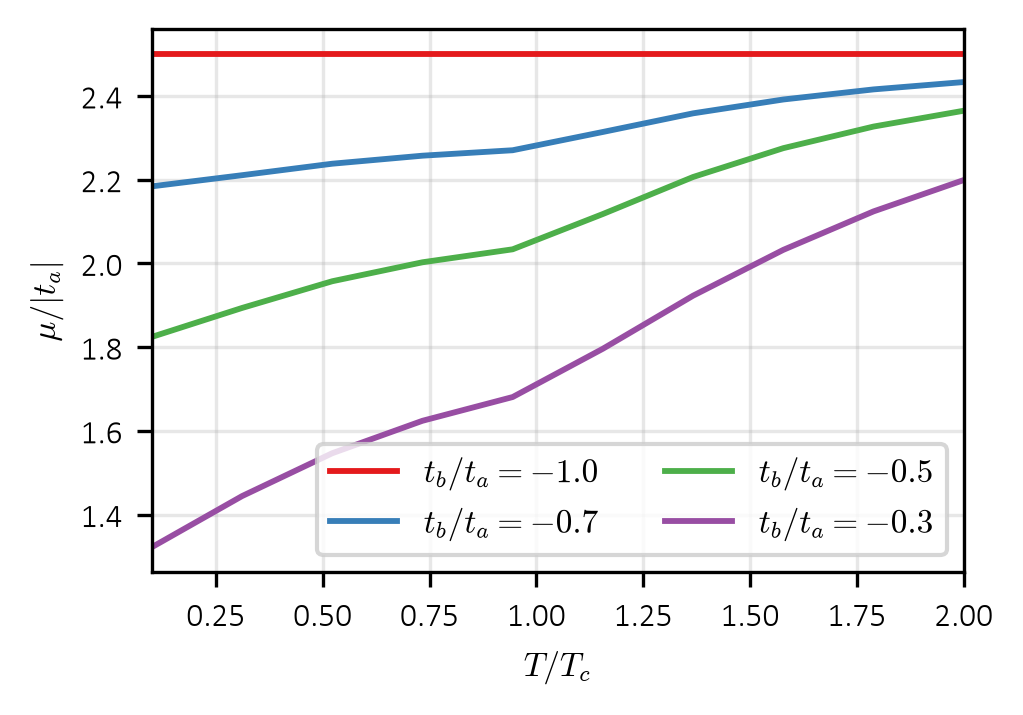

In [65]:
h = 0.7
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

for j in tqdm(range(tba.size), desc="Plotting"):
    ax.plot(
        xn,
        mua[j] / abs(ta),
        color=set1_list[j],
        linewidth=1.4,
        label=rf"$t_b/t_a={tba[j] / ta:.1f}$",
    )

ax.set_xlim(xn[0], xn[-1])
ax.set_xlabel(r"$T/T_c$")
ax.set_ylabel(r"$\mu/|t_a|$")

ax.grid(alpha=0.3)
ax.legend(
    ncol=2,
)

plt.tight_layout()
plt.show()

In [76]:
nv = 10
ng = 10

va = np.linspace(0.1, 7.0, nv)
ga = np.linspace(0.0, 2.3, ng)

da = np.full((ng, nv), np.nan)
ma = np.full_like(da, np.nan)
mua = np.full_like(da, np.nan)
era = np.full_like(da, np.nan)
oka = np.zeros((ng, nv), dtype=bool)

# Seed for the highest V point
dh = 1.0
mh = 0.0

bar = tqdm(range(ng), desc="Gap rows")

for j in bar:
    g0 = ga[j]

    bdq = eu.tb_2d(
        nk=nk,
        gap=float(g0),
        ta=ta,
        tb=tb,
    )

    # Start each row from the ordered side
    d = max(abs(dh), 0.1)
    m = mh

    for i in tqdm(
        range(nv),
        desc="V sweep",
        leave=False,
    ):
        v0 = va[i]

        pq = eu.MFPars(
            v=float(v0),
            n=1.0,
            uh=float(v0),
        )

        sq = eu.solve_eq(
            bdq,
            pq,
            t=0.1,
            d=max(abs(d), 1.0e-6),
            m=m,
            mix=(0.15, 0.15),
            tol=1.0e-5,
            nmax=20000,
            chk=20,
            prog=False,
        )

        da[j, i] = abs(sq.d)
        ma[j, i] = sq.m
        mua[j, i] = sq.mu
        era[j, i] = sq.err
        oka[j, i] = sq.ok

        d = sq.d
        m = sq.m

        # Save the high-V seed for the next Gap row
        if i == nv - 1:
            dh = sq.d
            mh = sq.m

    bar.set_postfix(
        gap=f"{g0:.2f}",
        dmax=f"{np.nanmax(da[j]):.3f}",
        err=f"{np.nanmax(era[j]):.2e}",
    )

logger.info(f"All converged: {np.all(oka)}")
logger.info(f"Failed points: {np.count_nonzero(~oka)}")
logger.info(f"Largest error: {np.nanmax(era)}")

Gap rows:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

...

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

[11:25:21] [INFO    ] All converged: True
[11:25:21] [INFO    ] Failed points: 0
[11:25:21] [INFO    ] Largest error: 9.99099281961957e-06


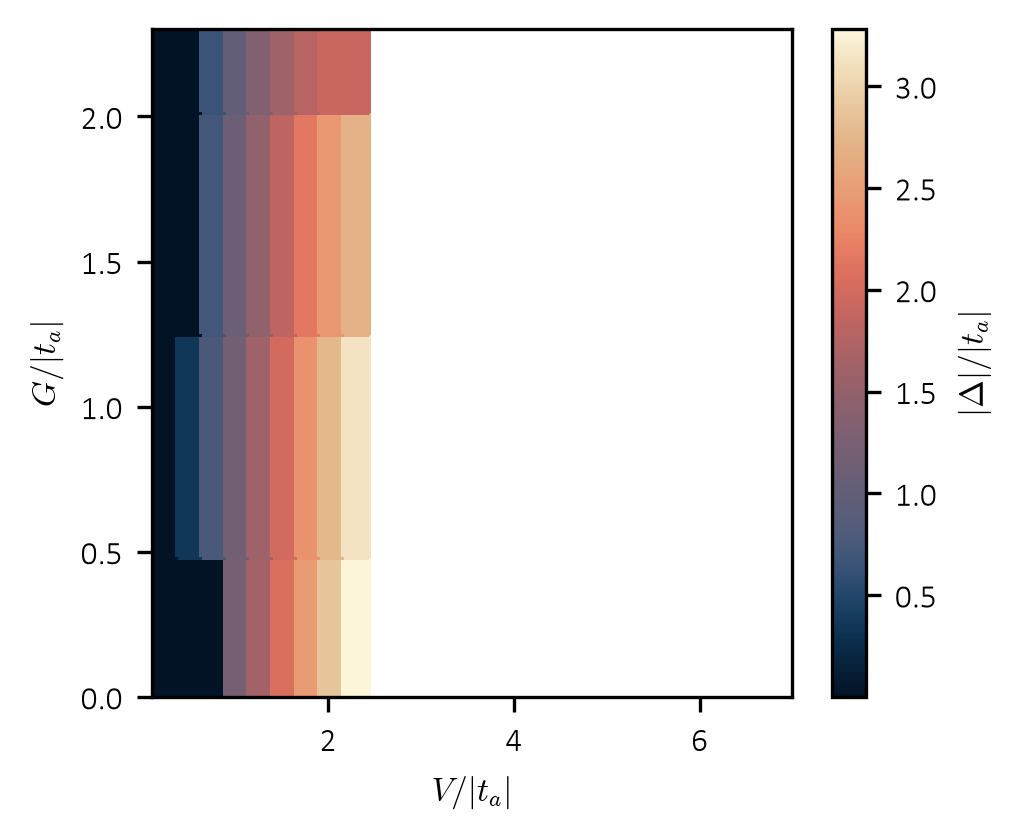

In [77]:
h = 0.82
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

im = ax.pcolormesh(
    ga / abs(ta),
    va / abs(ta),
    da / abs(ta),
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

ax.set_xlim(va[0] / abs(ta), va[-1] / abs(ta))
ax.set_ylim(ga[0] / abs(ta), ga[-1] / abs(ta))

ax.set_xlabel(r"$V/|t_a|$")
ax.set_ylabel(r"$G/|t_a|$")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    r"$|\Delta|/|t_a|$",
    rotation=90,
    labelpad=5,
)

plt.tight_layout()
plt.show()